# RQ1 - Internet Access

Analisi dell'esclusione da Internet nel dataset IACOFI 2023.

Il notebook produce:

1. pulizia e ricodifica delle variabili;
2. statistiche descrittive ponderate;
3. tabelle con intervalli di confidenza;
4. grafici per età e istruzione;
5. heatmap età × istruzione;
6. regressione logistica ponderata;
7. odds ratio e test globali di significatività;
8. probabilità aggiustate;
9. controlli di robustezza;
10. esportazione automatica dei risultati.

L'outcome `no_internet` vale 1 quando la persona non ha accesso a Internet e 0 quando dispone di accesso.

In [2]:
# Solo in Google Colab.
from google.colab import drive
drive.mount("/content/drive")

!pip -q install statsmodels openpyxl

Mounted at /content/drive


In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.special import expit
from patsy import build_design_matrices

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# MODIFICARE il percorso in base alla posizione del file su Drive.
DATA_PATH = Path("/content/drive/MyDrive/DSLAB_PROJECT/Database_ENG.dta")

OUTPUT_DIR = Path("/content/drive/MyDrive/RQ1_Internet_Access_Results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Output:", OUTPUT_DIR)

Dataset: /content/drive/MyDrive/DSLAB_PROJECT/Database_ENG.dta
Output: /content/drive/MyDrive/RQ1_Internet_Access_Results


## 1. Importazione e controllo del dataset

In [4]:
df_raw = pd.read_stata(
    DATA_PATH,
    convert_categoricals=False
)

required_columns = [
    "qd1", "qd2", "qd3", "qd7", "qd7_a",
    "qd9", "qd10", "qd13", "qd14", "wght"
]

missing_columns = sorted(set(required_columns) - set(df_raw.columns))

if missing_columns:
    raise KeyError(f"Variabili mancanti: {missing_columns}")

print(f"Osservazioni: {df_raw.shape[0]:,}")
print(f"Variabili: {df_raw.shape[1]:,}")
display(df_raw[required_columns].head())

Osservazioni: 4,862
Variabili: 219


,qd1,qd2,qd3,qd7,qd7_a,qd9,qd10,qd13,qd14,wght
0,1,1,3,68,NaN,5,6,2,1,0.401783
1,1,4,2,36,NaN,5,2,-99,1,0.639130
2,0,4,3,64,NaN,5,4,-99,1,0.852871
3,0,4,4,50,NaN,1,1,-99,1,0.951568
4,1,4,3,66,NaN,7,6,1,1,0.945395


## 2. Costruzione dell'outcome e ricodifica

In [5]:
rq1 = df_raw[required_columns].copy()

# Outcome: sono validi solamente 0 e 1.
rq1["internet_access"] = (
    rq1["qd14"]
    .where(rq1["qd14"].isin([0, 1]))
    .astype(float)
)
rq1["no_internet"] = 1 - rq1["internet_access"]

# Età esatta e fallback con QD7_a.
exact_age = rq1["qd7"].where(rq1["qd7"].between(18, 120))

age_group = pd.cut(
    exact_age,
    bins=[17, 29, 39, 49, 59, 69, np.inf],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"],
    include_lowest=True
).astype(object)

age_fallback = rq1["qd7_a"].map({
    1: "18-29",
    2: "18-29",
    3: "30-39",
    4: "40-49",
    5: "50-59",
    6: "60-69",
    7: "70+"
})

rq1["age_group"] = age_group.fillna(age_fallback)

rq1["gender"] = rq1["qd1"].map({
    1: "Uomo",
    0: "Donna"
})

rq1["region"] = rq1["qd2"].map({
    1: "Nord-Ovest",
    2: "Nord-Est",
    3: "Centro",
    4: "Sud",
    5: "Isole"
})

rq1["urbanisation"] = rq1["qd3"].map({
    1: "Area rurale (<3 mila)",
    2: "Piccolo comune (3-15 mila)",
    3: "Centro urbano (15-100 mila)",
    4: "Città (100 mila-1 milione)",
    5: "Grande città (>1 milione)"
})

rq1["education"] = rq1["qd9"].map({
    1: "Università",
    2: "Università",
    3: "Università",
    4: "Università",
    5: "Secondaria superiore",
    6: "Secondaria superiore",
    7: "Secondaria inferiore",
    8: "Secondaria inferiore",
    9: "Primaria o inferiore",
    10: "Primaria o inferiore"
})

rq1["work_status"] = rq1["qd10"].map({
    1: "Autonomo",
    2: "Occupato dipendente",
    3: "Apprendista",
    4: "Cura della casa",
    5: "Disoccupato",
    6: "Pensionato",
    7: "Inabile al lavoro",
    8: "Inattivo",
    9: "Studente",
    10: "Altro"
})

rq1["income_group"] = rq1["qd13"].map({
    3: "Oltre €2.900",
    2: "€1.751-€2.900",
    1: "Fino a €1.750",
    -97: "Non dichiarato",
    -99: "Non dichiarato"
})

category_orders = {
    "age_group": [
        "18-29", "30-39", "40-49", "50-59", "60-69", "70+"
    ],
    "gender": [
        "Uomo", "Donna"
    ],
    "education": [
        "Università",
        "Secondaria superiore",
        "Secondaria inferiore",
        "Primaria o inferiore"
    ],
    "work_status": [
        "Occupato dipendente",
        "Autonomo",
        "Apprendista",
        "Cura della casa",
        "Disoccupato",
        "Pensionato",
        "Inabile al lavoro",
        "Inattivo",
        "Studente",
        "Altro"
    ],
    "region": [
        "Nord-Ovest", "Nord-Est", "Centro", "Sud", "Isole"
    ],
    "urbanisation": [
        "Grande città (>1 milione)",
        "Città (100 mila-1 milione)",
        "Centro urbano (15-100 mila)",
        "Piccolo comune (3-15 mila)",
        "Area rurale (<3 mila)"
    ],
    "income_group": [
        "Oltre €2.900",
        "€1.751-€2.900",
        "Fino a €1.750",
        "Non dichiarato"
    ]
}

for column, order in category_orders.items():
    rq1[column] = pd.Categorical(
        rq1[column],
        categories=order,
        ordered=True
    )

display(rq1.head())

,qd1,qd2,qd3,qd7,qd7_a,qd9,qd10,qd13,qd14,wght,internet_access,no_internet,age_group,gender,region,urbanisation,education,work_status,income_group
0,1,1,3,68,NaN,5,6,2,1,0.401783,1.0,0.0,60-69,Uomo,Nord-Ovest,Centro urbano (15-100 mila),Secondaria superiore,Pensionato,€1.751-€2.900
1,1,4,2,36,NaN,5,2,-99,1,0.639130,1.0,0.0,30-39,Uomo,Sud,Piccolo comune (3-15 mila),Secondaria superiore,Occupato dipendente,Non dichiarato
2,0,4,3,64,NaN,5,4,-99,1,0.852871,1.0,0.0,60-69,Donna,Sud,Centro urbano (15-100 mila),Secondaria superiore,Cura della casa,Non dichiarato
3,0,4,4,50,NaN,1,1,-99,1,0.951568,1.0,0.0,50-59,Donna,Sud,Città (100 mila-1 milione),Università,Autonomo,Non dichiarato
4,1,4,3,66,NaN,7,6,1,1,0.945395,1.0,0.0,60-69,Uomo,Sud,Centro urbano (15-100 mila),Secondaria inferiore,Pensionato,Fino a €1.750


## 3. Controlli automatici

In [6]:
validation_table = pd.DataFrame({
    "Controllo": [
        "Accesso a Internet",
        "Nessun accesso",
        "Risposta mancante/non valida",
        "Totale osservazioni"
    ],
    "Numero": [
        int(rq1["internet_access"].eq(1).sum()),
        int(rq1["internet_access"].eq(0).sum()),
        int(rq1["internet_access"].isna().sum()),
        len(rq1)
    ]
})

display(validation_table)

assert rq1["internet_access"].eq(1).sum() == 4427
assert rq1["internet_access"].eq(0).sum() == 415
assert rq1["internet_access"].isna().sum() == 20
assert rq1["wght"].notna().all()
assert (rq1["wght"] > 0).all()

overall_valid = rq1.dropna(subset=["no_internet", "wght"])

weighted_no_internet = np.average(
    overall_valid["no_internet"],
    weights=overall_valid["wght"]
)

print(f"Senza Internet, ponderato: {100 * weighted_no_internet:.2f}%")
print(f"Con Internet, ponderato: {100 * (1 - weighted_no_internet):.2f}%")

,Controllo,Numero
0,Accesso a Internet,4427
1,Nessun accesso,415
2,Risposta mancante/non valida,20
3,Totale osservazioni,4862


Senza Internet, ponderato: 10.58%
Con Internet, ponderato: 89.42%


## 4. Tabelle descrittive ponderate

In [7]:
def weighted_binary_summary(
    frame,
    group,
    outcome="no_internet",
    weight="wght",
    alpha=0.05
):
    # Intervallo Wilson approssimato usando la numerosità
    # effettiva di Kish. Non sostituisce una stima survey
    # completa quando PSU e strati non sono disponibili.
    z = norm.ppf(1 - alpha / 2)

    use = frame.dropna(
        subset=[group, outcome, weight]
    ).copy()

    rows = []

    for level, group_data in use.groupby(
        group,
        observed=True,
        sort=True
    ):
        weights = group_data[weight].astype(float).to_numpy()
        values = group_data[outcome].astype(float).to_numpy()

        weighted_rate = np.average(values, weights=weights)

        effective_n = (
            weights.sum() ** 2
            / np.square(weights).sum()
        )

        denominator = 1 + z**2 / effective_n

        center = (
            weighted_rate
            + z**2 / (2 * effective_n)
        ) / denominator

        half_width = (
            z
            * np.sqrt(
                weighted_rate * (1 - weighted_rate) / effective_n
                + z**2 / (4 * effective_n**2)
            )
            / denominator
        )

        rows.append({
            group: level,
            "n": len(group_data),
            "eventi_no_internet": int(values.sum()),
            "peso_totale": weights.sum(),
            "n_effettivo": effective_n,
            "percentuale_ponderata": 100 * weighted_rate,
            "ci95_basso": 100 * max(0, center - half_width),
            "ci95_alto": 100 * min(1, center + half_width)
        })

    return pd.DataFrame(rows)


descriptive_variables = [
    "age_group",
    "education",
    "gender",
    "work_status",
    "region",
    "urbanisation",
    "income_group"
]

descriptive_tables = {
    variable: weighted_binary_summary(rq1, variable)
    for variable in descriptive_variables
}

display(
    descriptive_tables["age_group"].style.format({
        "peso_totale": "{:.1f}",
        "n_effettivo": "{:.1f}",
        "percentuale_ponderata": "{:.2f}%",
        "ci95_basso": "{:.2f}%",
        "ci95_alto": "{:.2f}%"
    })
)

display(
    descriptive_tables["education"].style.format({
        "peso_totale": "{:.1f}",
        "n_effettivo": "{:.1f}",
        "percentuale_ponderata": "{:.2f}%",
        "ci95_basso": "{:.2f}%",
        "ci95_alto": "{:.2f}%"
    })
)

,age_group,n,eventi_no_internet,peso_totale,n_effettivo,percentuale_ponderata,ci95_basso,ci95_alto
0,18-29,566,7,665.5,357.8,1.34%,0.56%,3.15%
1,30-39,875,5,887.0,669.7,0.70%,0.29%,1.67%
2,40-49,877,14,869.2,706.4,1.86%,1.10%,3.15%
3,50-59,955,32,979.3,745.6,5.11%,3.75%,6.94%
4,60-69,835,113,761.6,576.2,19.28%,16.26%,22.70%
5,70+,734,244,673.2,546.1,42.08%,38.01%,46.27%


,education,n,eventi_no_internet,peso_totale,n_effettivo,percentuale_ponderata,ci95_basso,ci95_alto
0,Università,1275,16,1129.2,1145.0,1.15%,0.67%,1.95%
1,Secondaria superiore,2847,142,2483.3,2026.4,4.89%,4.03%,5.91%
2,Secondaria inferiore,609,188,1065.3,516.9,26.21%,22.61%,30.17%
3,Primaria o inferiore,111,69,158.0,98.9,62.02%,52.17%,70.97%


## 5. Grafici descrittivi

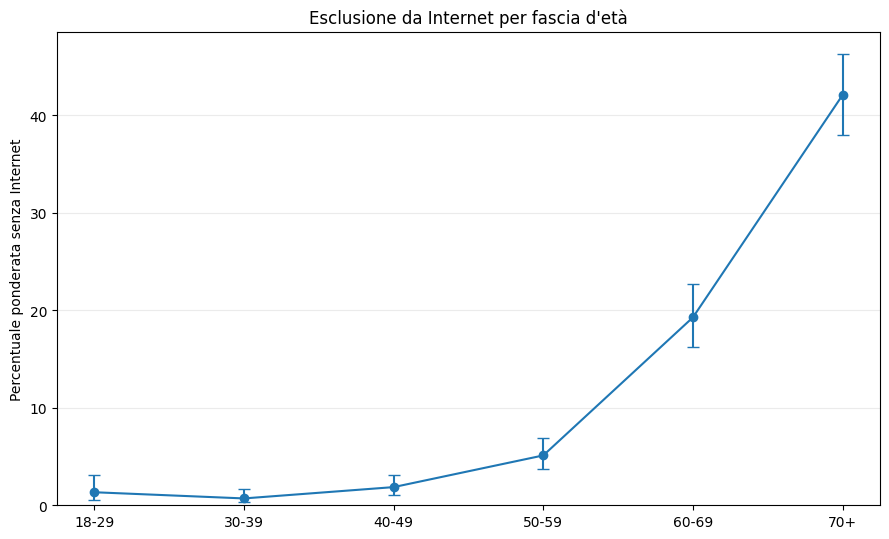

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/01_esclusione_per_eta.png


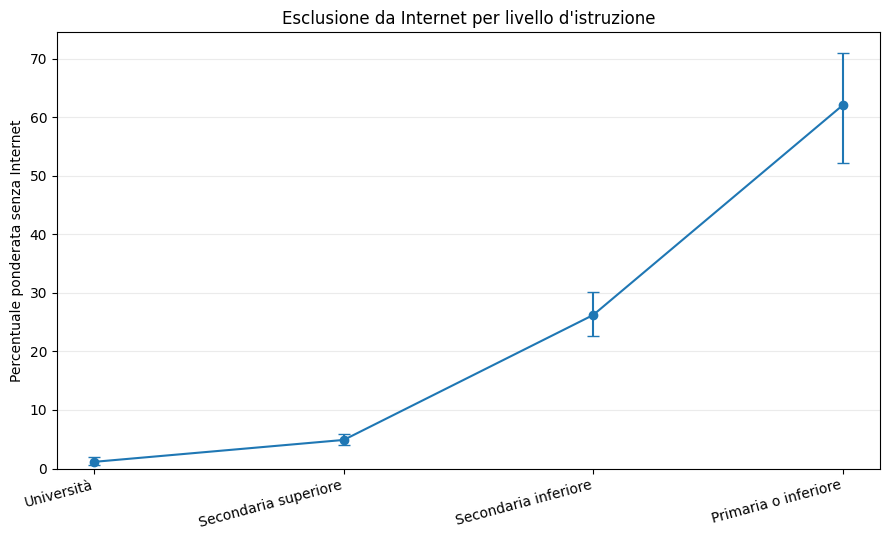

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/02_esclusione_per_istruzione.png


In [8]:
def plot_weighted_rate(
    table,
    category,
    title,
    filename,
    rotate=0
):
    figure, axis = plt.subplots(figsize=(9, 5.5))

    x = np.arange(len(table))
    y = table["percentuale_ponderata"].to_numpy()

    y_error = np.vstack([
        y - table["ci95_basso"].to_numpy(),
        table["ci95_alto"].to_numpy() - y
    ])

    axis.errorbar(
        x,
        y,
        yerr=y_error,
        fmt="o-",
        capsize=4
    )

    axis.set_xticks(x)
    axis.set_xticklabels(
        table[category].astype(str),
        rotation=rotate,
        ha="right" if rotate else "center"
    )
    axis.set_ylabel("Percentuale ponderata senza Internet")
    axis.set_title(title)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)

    figure.tight_layout()
    output_path = OUTPUT_DIR / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Salvato:", output_path)


plot_weighted_rate(
    descriptive_tables["age_group"],
    category="age_group",
    title="Esclusione da Internet per fascia d'età",
    filename="01_esclusione_per_eta.png"
)

plot_weighted_rate(
    descriptive_tables["education"],
    category="education",
    title="Esclusione da Internet per livello d'istruzione",
    filename="02_esclusione_per_istruzione.png",
    rotate=15
)

## 6. Heatmap età × istruzione

education,Università,Secondaria superiore,Secondaria inferiore,Primaria o inferiore
age_group,,,,
18-29,1.01,0.88,1.54,100.00
30-39,0.20,1.17,0.00,0.00
40-49,1.30,1.67,2.04,26.21
50-59,0.30,3.02,13.80,100.00
60-69,7.09,9.38,31.41,59.60
70+,2.61,22.90,52.02,69.60


education,Università,Secondaria superiore,Secondaria inferiore,Primaria o inferiore
age_group,,,,
18-29,186,340,39,1
30-39,353,488,30,4
40-49,324,499,50,4
50-59,236,626,91,2
60-69,103,548,154,30
70+,73,346,245,70


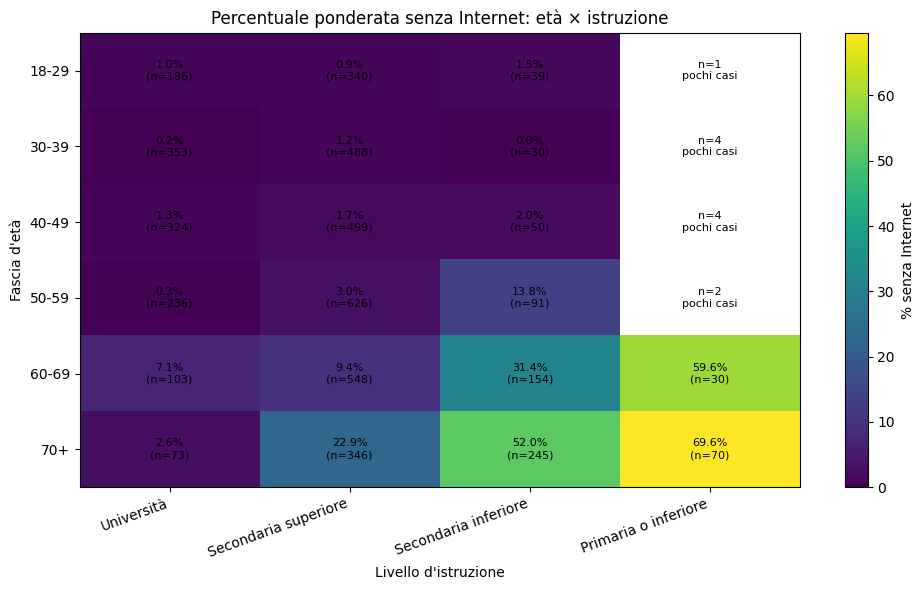

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/03_heatmap_eta_istruzione.png


In [9]:
def weighted_pivot(
    frame,
    row,
    column,
    outcome="no_internet",
    weight="wght"
):
    use = frame.dropna(subset=[row, column, outcome, weight])
    rows = []

    for (row_level, column_level), group_data in use.groupby(
        [row, column],
        observed=True,
        sort=True
    ):
        rows.append({
            row: row_level,
            column: column_level,
            "percentuale": 100 * np.average(
                group_data[outcome],
                weights=group_data[weight]
            ),
            "n": len(group_data)
        })

    long_table = pd.DataFrame(rows)

    percentage_table = long_table.pivot(
        index=row,
        columns=column,
        values="percentuale"
    )

    count_table = long_table.pivot(
        index=row,
        columns=column,
        values="n"
    )

    return percentage_table, count_table


heatmap_percentage, heatmap_count = weighted_pivot(
    rq1,
    row="age_group",
    column="education"
)

heatmap_percentage = heatmap_percentage.reindex(
    index=category_orders["age_group"],
    columns=category_orders["education"]
)

heatmap_count = heatmap_count.reindex(
    index=category_orders["age_group"],
    columns=category_orders["education"]
)

display(heatmap_percentage.round(2))
display(heatmap_count)


def plot_heatmap(
    percentage_table,
    count_table,
    filename,
    minimum_cell_n=30
):
    plot_values = percentage_table.copy()
    plot_values[count_table < minimum_cell_n] = np.nan

    figure, axis = plt.subplots(figsize=(10, 6))
    image = axis.imshow(
        plot_values.to_numpy(dtype=float),
        aspect="auto"
    )

    axis.set_xticks(np.arange(plot_values.shape[1]))
    axis.set_xticklabels(
        plot_values.columns.astype(str),
        rotation=20,
        ha="right"
    )

    axis.set_yticks(np.arange(plot_values.shape[0]))
    axis.set_yticklabels(plot_values.index.astype(str))

    axis.set_xlabel("Livello d'istruzione")
    axis.set_ylabel("Fascia d'età")
    axis.set_title(
        "Percentuale ponderata senza Internet: età × istruzione"
    )

    colorbar = figure.colorbar(image, ax=axis)
    colorbar.set_label("% senza Internet")

    percentages = percentage_table.to_numpy(dtype=float)
    counts = count_table.to_numpy(dtype=float)

    for row_index in range(percentages.shape[0]):
        for column_index in range(percentages.shape[1]):
            n = counts[row_index, column_index]

            if not np.isfinite(n):
                continue

            if n < minimum_cell_n:
                label = f"n={int(n)}\npochi casi"
            else:
                label = (
                    f"{percentages[row_index, column_index]:.1f}%"
                    f"\n(n={int(n)})"
                )

            axis.text(
                column_index,
                row_index,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    figure.tight_layout()
    output_path = OUTPUT_DIR / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Salvato:", output_path)


plot_heatmap(
    heatmap_percentage,
    heatmap_count,
    filename="03_heatmap_eta_istruzione.png",
    minimum_cell_n=30
)

## 7. Campione analitico

In [10]:
model_variables = [
    "no_internet",
    "age_group",
    "gender",
    "education",
    "work_status",
    "region",
    "urbanisation",
    "wght"
]

access_sample = rq1.dropna(subset=model_variables).copy()

categorical_model_variables = [
    "age_group",
    "gender",
    "education",
    "work_status",
    "region",
    "urbanisation"
]

for variable in categorical_model_variables:
    access_sample[variable] = (
        access_sample[variable]
        .cat.remove_unused_categories()
    )

sample_check = pd.DataFrame({
    "Indicatore": [
        "Osservazioni nel modello",
        "Persone senza Internet",
        "Persone con Internet"
    ],
    "Numero": [
        len(access_sample),
        int(access_sample["no_internet"].sum()),
        int(len(access_sample) - access_sample["no_internet"].sum())
    ]
})

display(sample_check)

,Indicatore,Numero
0,Osservazioni nel modello,4823
1,Persone senza Internet,415
2,Persone con Internet,4408


## 8. Regressione logistica ponderata

Categorie di riferimento:

- 18-29 anni;
- uomo;
- istruzione universitaria;
- occupato dipendente;
- Nord-Ovest;
- grande città.

Il modello usa `wght` e una matrice di covarianza robusta HC1. Poiché non sono disponibili tutte le informazioni su strati e PSU, la stima è pseudo-ponderata e non una stima survey completa.

In [11]:
formula_main = (
    "no_internet ~ "
    "C(age_group) + "
    "C(gender) + "
    "C(education) + "
    "C(work_status) + "
    "C(region) + "
    "C(urbanisation)"
)

main_model = smf.glm(
    formula=formula_main,
    data=access_sample,
    family=sm.families.Binomial(),
    freq_weights=access_sample["wght"]
).fit(
    cov_type="HC1",
    maxiter=200
)

print(main_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            no_internet   No. Observations:                 4823
Model:                            GLM   Df Residuals:                  4779.43
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1024.8
Date:                Sun, 09 Aug 2026   Deviance:                       2049.7
Time:                        10:38:38   Pearson chi2:                 5.70e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2217
Covariance Type:                  HC1                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

## 9. Odds ratio

In [12]:
def clean_term_name(term):
    if term == "Intercept":
        return "Intercetta"

    replacements = {
        "C(age_group)[T.": "Età: ",
        "C(gender)[T.": "Genere: ",
        "C(education)[T.": "Istruzione: ",
        "C(work_status)[T.": "Lavoro: ",
        "C(region)[T.": "Area: ",
        "C(urbanisation)[T.": "Urbanizzazione: ",
        "C(income_group)[T.": "Reddito: "
    }

    for original, replacement in replacements.items():
        if term.startswith(original):
            return replacement + term[len(original):-1]

    return term


def odds_ratio_table(result, model_name="Modello"):
    confidence_interval = result.conf_int()

    output = pd.DataFrame({
        "termine": result.params.index,
        "coefficiente": result.params.values,
        "odds_ratio": np.exp(result.params.values),
        "ci95_basso": np.exp(confidence_interval.iloc[:, 0].values),
        "ci95_alto": np.exp(confidence_interval.iloc[:, 1].values),
        "p_value": result.pvalues.values
    })

    output["variabile"] = output["termine"].map(clean_term_name)

    non_intercept = output["termine"].ne("Intercept")

    output.loc[non_intercept, "p_fdr"] = multipletests(
        output.loc[non_intercept, "p_value"],
        method="fdr_bh"
    )[1]

    output["significativita"] = pd.cut(
        output["p_value"],
        bins=[-np.inf, 0.001, 0.01, 0.05, np.inf],
        labels=["***", "**", "*", ""],
        right=False
    ).astype(str)

    output.insert(0, "modello", model_name)

    return output[
        [
            "modello",
            "variabile",
            "coefficiente",
            "odds_ratio",
            "ci95_basso",
            "ci95_alto",
            "p_value",
            "p_fdr",
            "significativita",
            "termine"
        ]
    ]


odds_ratios_main = odds_ratio_table(
    main_model,
    model_name="Ponderato"
)

display(
    odds_ratios_main[
        odds_ratios_main["termine"] != "Intercept"
    ].style.format({
        "coefficiente": "{:.3f}",
        "odds_ratio": "{:.2f}",
        "ci95_basso": "{:.2f}",
        "ci95_alto": "{:.2f}",
        "p_value": "{:.4f}",
        "p_fdr": "{:.4f}"
    })
)

,modello,variabile,coefficiente,odds_ratio,ci95_basso,ci95_alto,p_value,p_fdr,significativita,termine
1,Ponderato,Età: 30-39,-0.530,0.59,0.17,2.02,0.3999,0.5329,,C(age_group)[T.30-39]
2,Ponderato,Età: 40-49,0.309,1.36,0.49,3.80,0.5541,0.6926,,C(age_group)[T.40-49]
3,Ponderato,Età: 50-59,1.118,3.06,1.15,8.12,0.0247,0.0618,*,C(age_group)[T.50-59]
4,Ponderato,Età: 60-69,1.760,5.81,2.17,15.58,0.0005,0.0020,***,C(age_group)[T.60-69]
5,Ponderato,Età: 70+,2.439,11.46,4.18,31.41,0.0000,0.0000,***,C(age_group)[T.70+]
6,Ponderato,Genere: Donna,0.194,1.21,0.95,1.55,0.1194,0.2487,,C(gender)[T.Donna]
7,Ponderato,Istruzione: Secondaria superiore,0.815,2.26,1.23,4.15,0.0087,0.0243,**,C(education)[T.Secondaria superiore]
8,Ponderato,Istruzione: Secondaria inferiore,2.037,7.67,4.24,13.88,0.0000,0.0000,***,C(education)[T.Secondaria inferiore]
9,Ponderato,Istruzione: Primaria o inferiore,3.261,26.07,12.93,52.56,0.0000,0.0000,***,C(education)[T.Primaria o inferiore]
10,Ponderato,Lavoro: Autonomo,0.134,1.14,0.59,2.22,0.6928,0.8248,,C(work_status)[T.Autonomo]


## 10. Test globali di significatività

In [13]:
def wald_terms_table(result):
    output = (
        result
        .wald_test_terms(skip_single=False, scalar=True)
        .table
        .reset_index()
    )

    output = output.rename(columns={
        "index": "termine",
        "statistic": "chi2",
        "pvalue": "p_value",
        "df_constraint": "df"
    })

    labels = {
        "Intercept": "Intercetta",
        "C(age_group)": "Età",
        "C(gender)": "Genere",
        "C(education)": "Istruzione",
        "C(work_status)": "Condizione lavorativa",
        "C(region)": "Macroarea",
        "C(urbanisation)": "Urbanizzazione",
        "C(income_group)": "Reddito"
    }

    output["variabile"] = (
        output["termine"]
        .map(labels)
        .fillna(output["termine"])
    )

    return output[["variabile", "chi2", "df", "p_value"]]


wald_global_tests = wald_terms_table(main_model)

display(
    wald_global_tests.style.format({
        "chi2": "{:.2f}",
        "p_value": "{:.5f}"
    })
)

,variabile,chi2,df,p_value
0,Intercetta,93.84,1,0.00000
1,Età,76.98,5,0.00000
2,Genere,2.43,1,0.11938
3,Istruzione,189.17,3,0.00000
4,Condizione lavorativa,30.23,8,0.00019
5,Macroarea,13.53,4,0.00894
6,Urbanizzazione,18.72,4,0.00089


## 11. Probabilità aggiustate

In [14]:
def nearest_positive_semidefinite(
    matrix,
    minimum_eigenvalue=1e-12
):
    matrix = np.asarray(matrix, dtype=float)
    matrix = (matrix + matrix.T) / 2

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    eigenvalues = np.clip(
        eigenvalues,
        minimum_eigenvalue,
        None
    )

    return (eigenvectors * eigenvalues) @ eigenvectors.T


def adjusted_probabilities(
    result,
    frame,
    factor,
    levels=None,
    weight="wght",
    draws=2000,
    seed=12345
):
    # Average adjusted predictions:
    # ogni livello viene assegnato a tutto il campione,
    # mantenendo invariate le altre caratteristiche.
    if levels is None:
        levels = list(frame[factor].cat.categories)

    design_info = result.model.data.design_info
    coefficients = np.asarray(result.params)

    covariance = nearest_positive_semidefinite(
        result.cov_params()
    )

    random_generator = np.random.default_rng(seed)

    simulated_coefficients = random_generator.multivariate_normal(
        coefficients,
        covariance,
        size=draws
    )

    weights = frame[weight].to_numpy(dtype=float)
    weights = weights / weights.sum()

    rows = []

    for level in levels:
        scenario = frame.copy()

        scenario[factor] = pd.Categorical(
            [level] * len(scenario),
            categories=frame[factor].cat.categories,
            ordered=frame[factor].cat.ordered
        )

        design_matrix = np.asarray(
            build_design_matrices(
                [design_info],
                scenario,
                return_type="dataframe"
            )[0]
        )

        point_predictions = expit(
            design_matrix @ coefficients
        )

        adjusted_probability = np.average(
            point_predictions,
            weights=weights
        )

        simulated_predictions = expit(
            design_matrix @ simulated_coefficients.T
        )

        simulated_averages = weights @ simulated_predictions

        confidence_low, confidence_high = np.quantile(
            simulated_averages,
            [0.025, 0.975]
        )

        rows.append({
            factor: level,
            "probabilita_aggiustata": 100 * adjusted_probability,
            "ci95_basso": 100 * confidence_low,
            "ci95_alto": 100 * confidence_high
        })

    return pd.DataFrame(rows)


adjusted_age = adjusted_probabilities(
    main_model,
    access_sample,
    factor="age_group"
)

adjusted_education = adjusted_probabilities(
    main_model,
    access_sample,
    factor="education"
)

display(
    adjusted_age.style.format({
        "probabilita_aggiustata": "{:.2f}%",
        "ci95_basso": "{:.2f}%",
        "ci95_alto": "{:.2f}%"
    })
)

display(
    adjusted_education.style.format({
        "probabilita_aggiustata": "{:.2f}%",
        "ci95_basso": "{:.2f}%",
        "ci95_alto": "{:.2f}%"
    })
)

,age_group,probabilita_aggiustata,ci95_basso,ci95_alto
0,18-29,2.90%,1.33%,6.55%
1,30-39,1.79%,0.85%,3.79%
2,40-49,3.82%,2.45%,6.14%
3,50-59,7.52%,5.88%,9.76%
4,60-69,12.22%,10.59%,14.63%
5,70+,19.31%,16.47%,23.63%


,education,probabilita_aggiustata,ci95_basso,ci95_alto
0,Università,3.01%,1.81%,5.06%
1,Secondaria superiore,6.12%,5.27%,7.33%
2,Secondaria inferiore,15.19%,13.98%,17.05%
3,Primaria o inferiore,30.13%,24.79%,37.05%


## 12. Grafici delle probabilità aggiustate

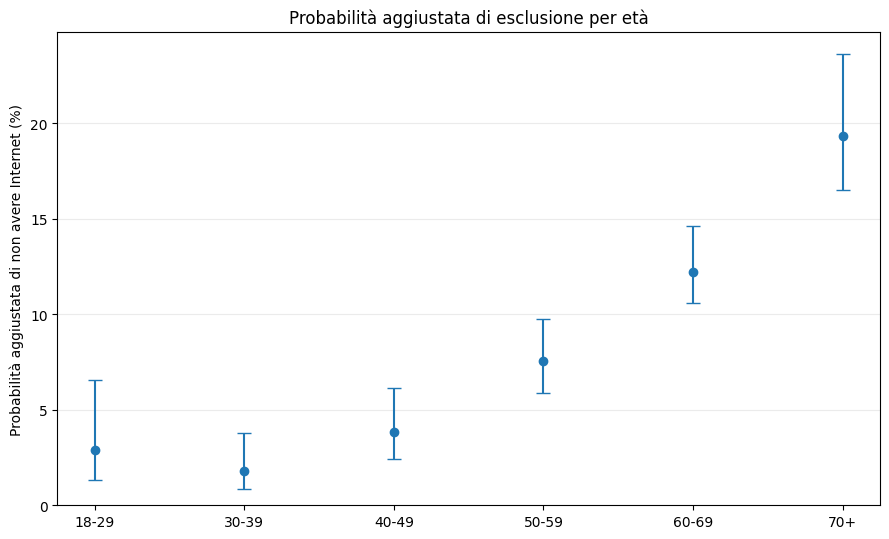

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/04_probabilita_aggiustata_eta.png


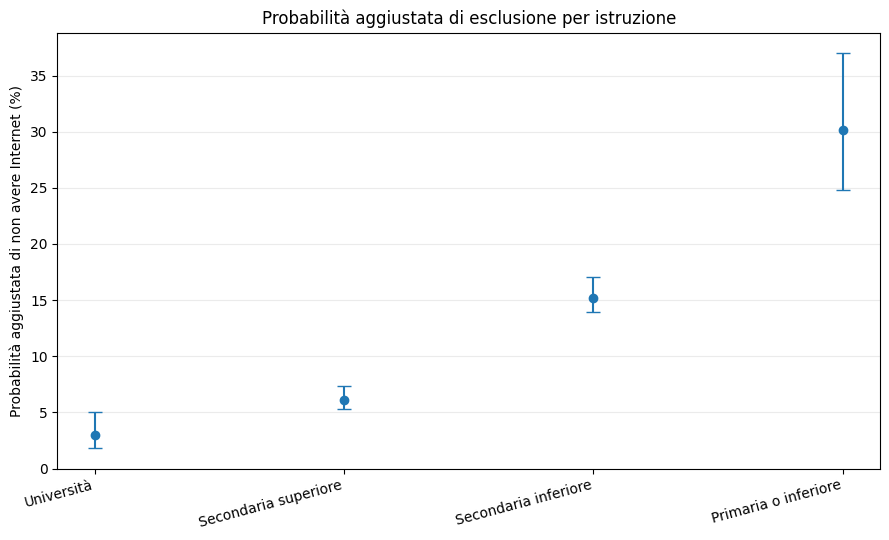

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/05_probabilita_aggiustata_istruzione.png


In [15]:
def plot_adjusted_probabilities(
    table,
    category,
    title,
    filename,
    rotate=0
):
    figure, axis = plt.subplots(figsize=(9, 5.5))

    x = np.arange(len(table))
    y = table["probabilita_aggiustata"].to_numpy()

    y_error = np.vstack([
        y - table["ci95_basso"].to_numpy(),
        table["ci95_alto"].to_numpy() - y
    ])

    axis.errorbar(
        x,
        y,
        yerr=y_error,
        fmt="o",
        capsize=5
    )

    axis.set_xticks(x)
    axis.set_xticklabels(
        table[category].astype(str),
        rotation=rotate,
        ha="right" if rotate else "center"
    )

    axis.set_ylabel(
        "Probabilità aggiustata di non avere Internet (%)"
    )
    axis.set_title(title)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", alpha=0.25)

    figure.tight_layout()
    output_path = OUTPUT_DIR / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Salvato:", output_path)


plot_adjusted_probabilities(
    adjusted_age,
    category="age_group",
    title="Probabilità aggiustata di esclusione per età",
    filename="04_probabilita_aggiustata_eta.png"
)

plot_adjusted_probabilities(
    adjusted_education,
    category="education",
    title="Probabilità aggiustata di esclusione per istruzione",
    filename="05_probabilita_aggiustata_istruzione.png",
    rotate=15
)

## 13. Coefficient plot

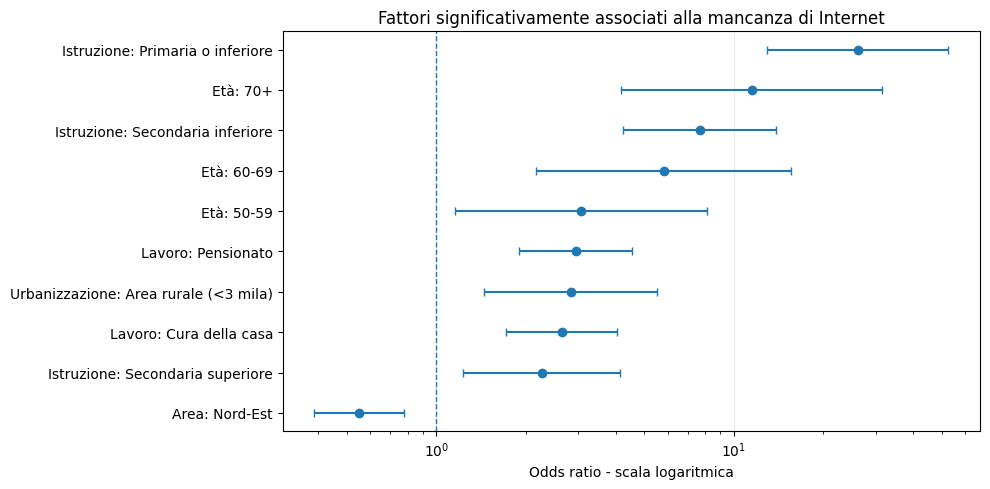

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/06_coefficient_plot.png


In [16]:
def plot_forest(
    odds_ratio_data,
    filename,
    p_threshold=0.05
):
    plot_data = odds_ratio_data[
        (odds_ratio_data["termine"] != "Intercept")
        & (odds_ratio_data["p_value"] < p_threshold)
    ].copy()

    plot_data = plot_data.sort_values("odds_ratio")

    figure_height = max(5, 0.45 * len(plot_data))
    figure, axis = plt.subplots(figsize=(10, figure_height))

    y = np.arange(len(plot_data))
    odds_ratio = plot_data["odds_ratio"].to_numpy()

    x_error = np.vstack([
        odds_ratio - plot_data["ci95_basso"].to_numpy(),
        plot_data["ci95_alto"].to_numpy() - odds_ratio
    ])

    axis.errorbar(
        odds_ratio,
        y,
        xerr=x_error,
        fmt="o",
        capsize=3
    )

    axis.axvline(1, linestyle="--", linewidth=1)
    axis.set_yticks(y)
    axis.set_yticklabels(plot_data["variabile"])
    axis.set_xscale("log")
    axis.set_xlabel("Odds ratio - scala logaritmica")
    axis.set_title(
        "Fattori significativamente associati alla mancanza di Internet"
    )
    axis.grid(axis="x", alpha=0.25)

    figure.tight_layout()
    output_path = OUTPUT_DIR / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Salvato:", output_path)


plot_forest(
    odds_ratios_main,
    filename="06_coefficient_plot.png"
)

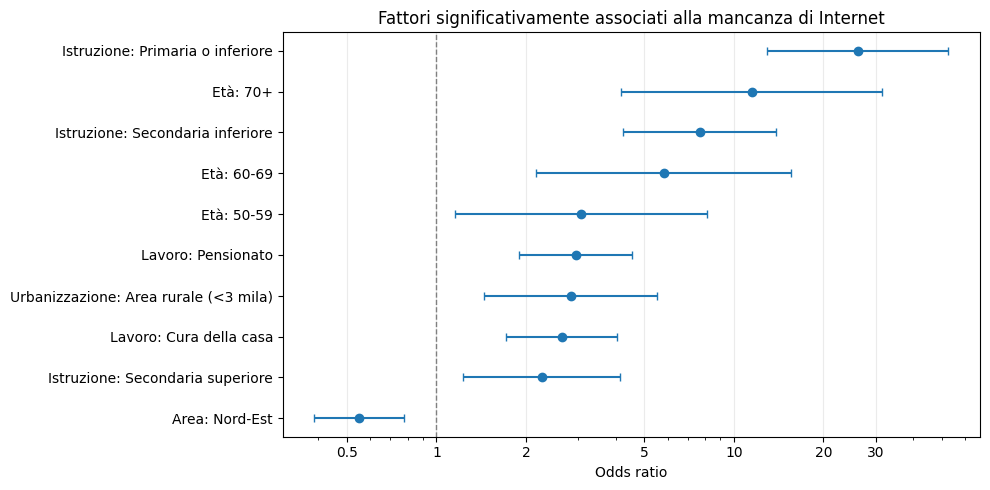

Salvato: /content/drive/MyDrive/RQ1_Internet_Access_Results/06_coefficient_plot.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def plot_forest(
    odds_ratio_data,
    filename,
    p_threshold=0.05
):
    plot_data = odds_ratio_data[
        (odds_ratio_data["termine"] != "Intercept")
        & (odds_ratio_data["p_value"] < p_threshold)
    ].copy()

    plot_data = plot_data.sort_values("odds_ratio")

    figure_height = max(5, 0.45 * len(plot_data))
    figure, axis = plt.subplots(figsize=(10, figure_height))

    y = np.arange(len(plot_data))
    odds_ratio = plot_data["odds_ratio"].to_numpy()

    x_error = np.vstack([
        odds_ratio - plot_data["ci95_basso"].to_numpy(),
        plot_data["ci95_alto"].to_numpy() - odds_ratio
    ])

    axis.errorbar(
        odds_ratio,
        y,
        xerr=x_error,
        fmt="o",
        capsize=3
    )

    axis.axvline(1, linestyle="--", linewidth=1, color="gray")
    axis.set_yticks(y)
    axis.set_yticklabels(plot_data["variabile"])

    # asse logaritmico con numeri leggibili
    axis.set_xscale("log")
    axis.set_xticks([0.5, 1, 2, 5, 10, 20, 30])
    axis.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{x:g}")
    )
    axis.xaxis.set_minor_formatter(mticker.NullFormatter())

    axis.set_xlabel("Odds ratio")
    axis.set_title(
        "Fattori significativamente associati alla mancanza di Internet"
    )
    axis.grid(axis="x", alpha=0.25)

    figure.tight_layout()
    output_path = OUTPUT_DIR / filename
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Salvato:", output_path)


plot_forest(
    odds_ratios_main,
    filename="06_coefficient_plot.png"
)

## 14. Controlli di robustezza

In [18]:
unweighted_model = smf.logit(
    formula_main,
    data=access_sample
).fit(
    disp=False,
    cov_type="HC1",
    maxiter=200
)

income_model_variables = model_variables + ["income_group"]

access_sample_income = rq1.dropna(
    subset=income_model_variables
).copy()

for variable in categorical_model_variables + ["income_group"]:
    access_sample_income[variable] = (
        access_sample_income[variable]
        .cat.remove_unused_categories()
    )

formula_income = formula_main + " + C(income_group)"

weighted_income_model = smf.glm(
    formula=formula_income,
    data=access_sample_income,
    family=sm.families.Binomial(),
    freq_weights=access_sample_income["wght"]
).fit(
    cov_type="HC1",
    maxiter=200
)

robustness_table = pd.concat(
    [
        odds_ratio_table(
            unweighted_model,
            model_name="Non ponderato"
        ),
        odds_ratio_table(
            main_model,
            model_name="Ponderato"
        ),
        odds_ratio_table(
            weighted_income_model,
            model_name="Ponderato + reddito"
        )
    ],
    ignore_index=True
)

key_terms = robustness_table[
    robustness_table["variabile"].str.contains(
        "Età:|Istruzione:|Urbanizzazione:|Genere:",
        regex=True
    )
].copy()

display(
    key_terms.style.format({
        "coefficiente": "{:.3f}",
        "odds_ratio": "{:.2f}",
        "ci95_basso": "{:.2f}",
        "ci95_alto": "{:.2f}",
        "p_value": "{:.4f}",
        "p_fdr": "{:.4f}"
    })
)

,modello,variabile,coefficiente,odds_ratio,ci95_basso,ci95_alto,p_value,p_fdr,significativita,termine
1,Non ponderato,Età: 30-39,-0.477,0.62,0.15,2.64,0.5184,0.8100,,C(age_group)[T.30-39]
2,Non ponderato,Età: 40-49,0.502,1.65,0.47,5.78,0.4321,0.7202,,C(age_group)[T.40-49]
3,Non ponderato,Età: 50-59,1.050,2.86,0.86,9.55,0.0881,0.2096,,C(age_group)[T.50-59]
4,Non ponderato,Età: 60-69,1.746,5.73,1.71,19.21,0.0047,0.0194,**,C(age_group)[T.60-69]
5,Non ponderato,Età: 70+,2.472,11.84,3.47,40.45,0.0001,0.0007,***,C(age_group)[T.70+]
6,Non ponderato,Genere: Donna,0.214,1.24,0.96,1.60,0.1006,0.2096,,C(gender)[T.Donna]
7,Non ponderato,Istruzione: Secondaria superiore,0.865,2.37,1.38,4.08,0.0017,0.0087,**,C(education)[T.Secondaria superiore]
8,Non ponderato,Istruzione: Secondaria inferiore,2.304,10.01,5.83,17.20,0.0000,0.0000,***,C(education)[T.Secondaria inferiore]
9,Non ponderato,Istruzione: Primaria o inferiore,3.346,28.40,14.36,56.14,0.0000,0.0000,***,C(education)[T.Primaria o inferiore]
22,Non ponderato,Urbanizzazione: Città (100 mila-1 milione),0.149,1.16,0.55,2.46,0.6979,0.9195,,C(urbanisation)[T.Città (100 mila-1 milione)]


## 15. Risultati significativi

In [19]:
significant_results = (
    odds_ratios_main[
        (odds_ratios_main["termine"] != "Intercept")
        & (odds_ratios_main["p_value"] < 0.05)
    ]
    .sort_values("odds_ratio", ascending=False)
)

display(
    significant_results[
        [
            "variabile",
            "odds_ratio",
            "ci95_basso",
            "ci95_alto",
            "p_value",
            "p_fdr",
            "significativita"
        ]
    ].style.format({
        "odds_ratio": "{:.2f}",
        "ci95_basso": "{:.2f}",
        "ci95_alto": "{:.2f}",
        "p_value": "{:.5f}",
        "p_fdr": "{:.5f}"
    })
)

print(
    "Un odds ratio superiore a 1 indica maggiori odds "
    "di non avere Internet rispetto alla categoria di riferimento."
)

,variabile,odds_ratio,ci95_basso,ci95_alto,p_value,p_fdr,significativita
9,Istruzione: Primaria o inferiore,26.07,12.93,52.56,0.00000,0.00000,***
5,Età: 70+,11.46,4.18,31.41,0.00000,0.00001,***
8,Istruzione: Secondaria inferiore,7.67,4.24,13.88,0.00000,0.00000,***
4,Età: 60-69,5.81,2.17,15.58,0.00047,0.00196,***
3,Età: 50-59,3.06,1.15,8.12,0.02472,0.06180,*
14,Lavoro: Pensionato,2.94,1.90,4.54,0.00000,0.00001,***
25,Urbanizzazione: Area rurale (<3 mila),2.83,1.45,5.52,0.00232,0.00724,**
12,Lavoro: Cura della casa,2.63,1.71,4.06,0.00001,0.00006,***
7,Istruzione: Secondaria superiore,2.26,1.23,4.15,0.00875,0.02429,**
18,Area: Nord-Est,0.55,0.39,0.78,0.00066,0.00234,***


Un odds ratio superiore a 1 indica maggiori odds di non avere Internet rispetto alla categoria di riferimento.


## 16. Esportazione

In [20]:
excel_path = OUTPUT_DIR / "RQ1_internet_access_results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    validation_table.to_excel(
        writer,
        sheet_name="validazione",
        index=False
    )

    for name, table in descriptive_tables.items():
        table.to_excel(
            writer,
            sheet_name=f"desc_{name}"[:31],
            index=False
        )

    odds_ratios_main.drop(columns="termine").to_excel(
        writer,
        sheet_name="odds_ratio",
        index=False
    )

    wald_global_tests.to_excel(
        writer,
        sheet_name="test_globali",
        index=False
    )

    robustness_table.drop(columns="termine").to_excel(
        writer,
        sheet_name="robustezza",
        index=False
    )

    adjusted_age.to_excel(
        writer,
        sheet_name="prob_aggiustate_eta",
        index=False
    )

    adjusted_education.to_excel(
        writer,
        sheet_name="prob_aggiustate_istr",
        index=False
    )

    heatmap_percentage.to_excel(
        writer,
        sheet_name="heatmap_percentuali"
    )

    heatmap_count.to_excel(
        writer,
        sheet_name="heatmap_n"
    )

clean_dataset_path = OUTPUT_DIR / "RQ1_internet_access_clean.csv"
rq1.to_csv(clean_dataset_path, index=False)

print("File Excel:", excel_path)
print("Dataset pulito:", clean_dataset_path)
print("Grafici:", OUTPUT_DIR)

File Excel: /content/drive/MyDrive/RQ1_Internet_Access_Results/RQ1_internet_access_results.xlsx
Dataset pulito: /content/drive/MyDrive/RQ1_Internet_Access_Results/RQ1_internet_access_clean.csv
Grafici: /content/drive/MyDrive/RQ1_Internet_Access_Results
